In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 한글 깨짐 방지 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 그래프 크기 설정
plt.figure(figsize=(6, 3))

<Figure size 600x300 with 0 Axes>

<Figure size 600x300 with 0 Axes>

### EX-1. 세로 막대 그래프
#### 과목별 점수를 세로 막대그래프로 표현하시오 
#### 그래프 제목: "과목별 점수" 
#### x축: 과목 / y축: 점수 
#### 막대 위에 점수 값 표시
#### 아래 데이터를 이용해 작성하시오.
#### Python 항목 부분에만 레이블 값이 출력되도록 수정하세요.

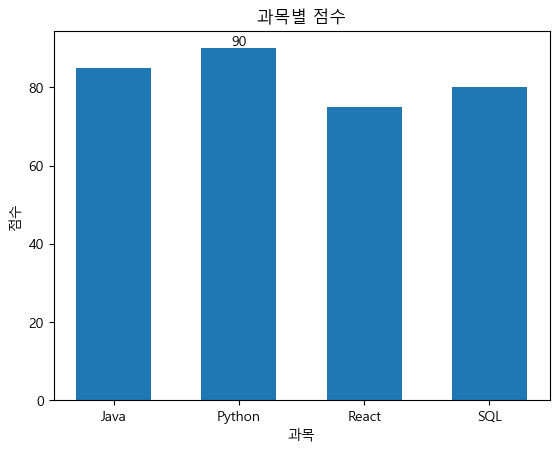

In [49]:
df = pd.DataFrame({
    "점수": [85, 90, 75, 80],
    "과목": ["Java", "Python", "React", "SQL"]
})

bars = plt.bar(
    df['과목'],
    df['점수'],
    width=0.6
)

for i in range(len(bars)):
    if df['과목'].iloc[i] == "Python":
        bar = bars[i]
        height = bar.get_height()  # 세로막대 값
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{int(height)}',
            ha='center',
            va='bottom'
        )

plt.title("과목별 점수")
plt.xlabel("과목")
plt.ylabel("점수")
plt.show()


### EX-2. 가로 막대 그래프
#### • 공부시간을 가로 막대그래프로 표현하시오
#### • 막대 두께를 0.5로 설정
#### • 그래프 제목: "학생별 공부시간“
#### • 아래 데이터를 이용해 작성하시오.

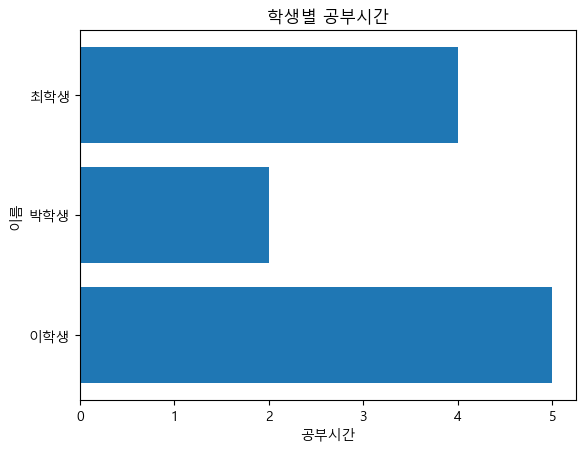

In [53]:
df = pd.DataFrame({
    "이름": ["김학생", "이학생", "박학생", "최학생"],
    "공부시간": [3, 5, 2, 4]
})
df = df[df['이름'] != '김학생']
bars = plt.barh(df["이름"], df["공부시간"])

plt.title("학생별 공부시간")
plt.xlabel("공부시간")
plt.ylabel("이름")
plt.show()

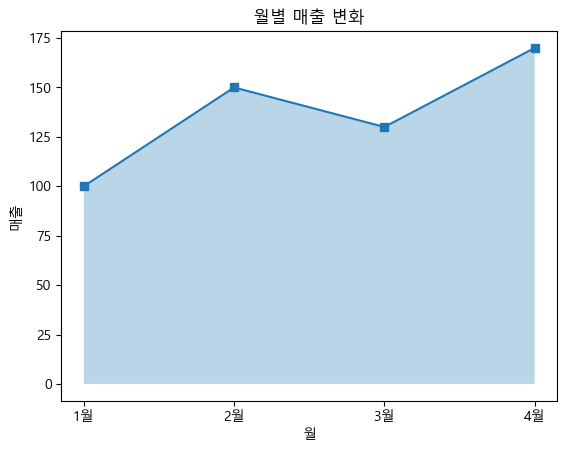

In [55]:
# • 매출 데이터를 선그래프로 표현
# • marker 추가
# • 선 아래 영역을 색으로 채우기
# • 그래프 제목: "월별 매출 변화"
# • 아래 데이터를 이용해 작성하시오.

df = pd.DataFrame({
    "월": ["1월", "2월", "3월", "4월"],
    "매출": [100, 150, 130, 170]
})

plots = plt.plot(df['월'], df['매출'], marker='s')
plt.title('월별 매출 변화')
plt.xlabel('월')
plt.ylabel('매출')
plt.fill_between(df['월'], df['매출'], alpha=0.3)
plt.show()

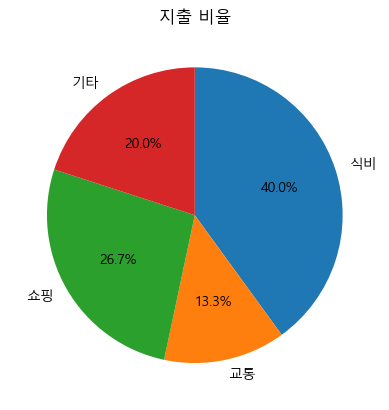

In [58]:
# • 금액을 기준으로 원형 그래프 생성
# • 퍼센트 표시
# • 시작 각도 90도 설정
# • 그래프 제목: "지출 비율“
# • 아래 데이터를 이용해 작성하시오.

df = pd.DataFrame({
    "카테고리": ["식비", "교통", "쇼핑", "기타"],
    "금액": [300000, 100000, 200000, 150000]
})
plt.pie(
    df['금액'],
    autopct='%1.1f%%',
    labels=df["카테고리"],
    startangle=90,
    counterclock=False
)
plt.title('지출 비율')
plt.show()

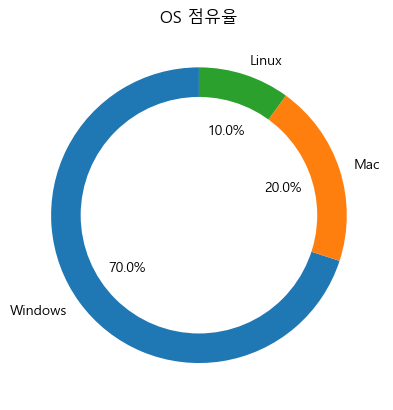

In [64]:
# • 사용자 비율을 도넛 그래프로 표현
# • 가운데 원 추가
# • 그래프 제목: "OS 점유율"
# • 아래 데이터를 이용해 작성하시오.

df = pd.DataFrame({
    "OS": ["Windows", "Mac", "Linux"],
    "사용자수": [70, 20, 10]
})
plt.pie(
    df['사용자수'],
    autopct='%1.1f%%',
    labels=df["OS"],
    startangle=90,
)
# 가운데 원 추가
center_circle = plt.Circle((0, 0), 0.8, fc='white')
plt.gca().add_artist(center_circle)
plt.title('OS 점유율')
plt.show()

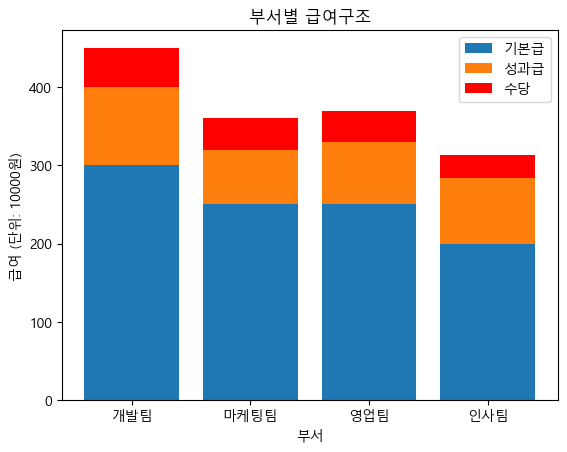

,부서,기본급,성과급,수당
0,개발팀,300.0,100.000000,50.0
1,마케팅팀,250.0,70.000000,40.0
2,영업팀,250.0,80.000000,40.0
3,인사팀,200.0,83.333333,30.0


In [110]:
# • 두 데이터를 부서 기준으로 병합하시오 (outer 조인)
# • 결측치는 각 컬럼의 평균값으로 처리하시오
# • 기본급과 성과급을 이용하여
# • 누적 세로 막대그래프를 생성하시오
# • 그래프 구성:
# • 아래: 기본급
# • 위: 성과급 (누적)
# 수당
# • 범례(legend) 추가
# • 그래프 제목: "부서별 급여 구조"
# • x축: 부서 / y축: 금액
# • 그래프를 이미지로 저장 (salary_chart.png, dpi=300)


df1 = pd.DataFrame({
    "부서": ["개발팀", "영업팀", "인사팀"],
    "기본급": [300, 250, 200]
})
df2 = pd.DataFrame({
    "부서": ["개발팀", "영업팀", "마케팅팀"],
    "성과급": [100, 80, 70]
})
df3 = pd.DataFrame({
    "부서": ["개발팀", "영업팀", "인사팀"],
    "수당": [50, 40, 30]
})

merged_df = pd.merge(df1, df2, on="부서", how="outer")
merged_df02 = pd.merge(merged_df, df3, on='부서', how='outer')
merged_df02['기본급'] = merged_df02['기본급'].fillna(df1['기본급'].mean())
merged_df02['성과급'] = merged_df02['성과급'].fillna(df2['성과급'].mean())
merged_df02['수당'] = merged_df02['수당'].fillna(df3['수당'].mean())
# merged_df02

plt.bar(merged_df02['부서'], merged_df02['기본급'], label='기본급')
plt.bar(
    merged_df02['부서'],
    merged_df02['성과급'],
    label='성과급',
    bottom=merged_df02['기본급']
)
plt.bar(
    merged_df02['부서'],
    merged_df02['수당'],
    label='수당',
    bottom=merged_df02['기본급'] + merged_df02['성과급'],
    color='red'
)

plt.title("부서별 급여구조")
plt.xlabel("부서")
plt.ylabel("급여 (단위: 10000원)")

# 범례 생성
plt.legend()

plt.show()

merged_df02